# Modelado de Series de Tiempo · Pronóstico de Demanda
## Proyecto Final: Smart Supply Chain

## Justificación

El enunciado del proyecto pide explícitamente:

> *“**Modelado de Series de Tiempo:** Construcción de modelos predictivos orientados a pronosticar la demanda futura a nivel de SKU y por sucursal. El objetivo primordial es establecer un sistema de **alertas tempranas que anticipe posibles quiebres de inventario (stockouts) o excesos de almacenamiento**.”* — INSTRUCCIONES.md

El proyecto previo no había abordado este componente. Este notebook lo cubre.

## Decisiones metodológicas

| Aspecto | Decisión | Por qué |
|---|---|---|
| Unidad muestral | demanda diaria por **categoría de producto** (`product_category_name_english`) | Olist no tiene tiendas físicas ni inventario real → no hay verdadero SKU-store. Categoría es la mayor granularidad estable que conserva volumen suficiente para SARIMA. |
| Ventana | 2016-09-04 a 2018-09-03 (730 días, 104 semanas) | Cubre dos ciclos anuales. |
| Train/Test | 700 días train / últimos 30 días test (rolling-origin) | Validación honesta sin fuga de información. |
| Modelos | SARIMA(1,1,1)(1,1,1,7) + Naïve estacional (baseline) | Captura tendencia y estacionalidad semanal. La estacionalidad anual no cabe (necesitaría ≥ 2 años completos en train). |
| Métricas | MAE, RMSE, MAPE, sMAPE | sMAPE es robusto a valores cercanos a cero (días con baja demanda). |
| Sistema de alertas | Bandas P10/P90 históricas + intervalo de confianza del pronóstico | Alerta de **stockout** cuando el límite superior del pronóstico supera P90; alerta de **sobre-stock** cuando el inferior cae por debajo de P10. |
| Categorías analizadas | Top 5 por volumen | El profesor pide priorización; reabastecer las 5 categorías con más demanda cubre ~50 % del volumen total. |

In [1]:
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tools.sm_exceptions import ConvergenceWarning, ValueWarning

CSV_DIR = os.environ.get('CSV_DIR', '../CSV')

# Silenciar solo el ruido habitual de SARIMA y cambios de API.
warnings.filterwarnings('ignore', category=ConvergenceWarning)
warnings.filterwarnings('ignore', category=ValueWarning)
warnings.filterwarnings('ignore', category=FutureWarning)

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.2f}'.format)


## 1. Construcción de las series y matriz exógena

Cargamos `tad_ventas` (con la columna `product_category_name_english` corregida) y construimos series diarias por categoría. Excluimos pedidos cancelados o no entregados porque no representan demanda real cumplida.

Adicionalmente cargamos `04_dim_calendario.csv` (notebook 04) para construir, en paralelo a cada serie, una **matriz exógena** que SARIMAX usará como regresor — esto materializa el aporte real de la fuente exógena al pronóstico, más allá de su uso en el modelo de retrasos.


In [2]:
tad_ventas = pd.read_csv(os.path.join(CSV_DIR, '02_tad_ventas.csv'),
                          usecols=['order_purchase_timestamp',
                                   'product_category_name_english',
                                   'order_status',
                                   'price'])
tad_ventas['order_purchase_timestamp'] = pd.to_datetime(
    tad_ventas['order_purchase_timestamp']
)
tad_ventas = tad_ventas[tad_ventas['order_status'].isin(
    ['delivered', 'shipped', 'invoiced', 'processing', 'approved']
)]

tad_ventas['fecha'] = tad_ventas['order_purchase_timestamp'].dt.normalize()

# Calendario exógeno (notebook 04)
dim_calendario = pd.read_csv(os.path.join(CSV_DIR, '04_dim_calendario.csv'),
                              parse_dates=['fecha'])

TOP_N = 5
top_cats = (
    tad_ventas['product_category_name_english']
    .value_counts().head(TOP_N).index.tolist()
)
print(f'Top {TOP_N} categorías por volumen:')
print(tad_ventas['product_category_name_english'].value_counts().head(TOP_N))
print('\nCalendario exógeno cargado:', dim_calendario.shape)


Top 5 categorías por volumen:
product_category_name_english
bed_bath_table           11097
health_beauty             9634
sports_leisure            8590
furniture_decor           8298
computers_accessories     7781
Name: count, dtype: int64

Calendario exógeno cargado: (1096, 15)


In [3]:
# Pivot a panel diario (items vendidos) y panel de revenue
panel = (
    tad_ventas[tad_ventas['product_category_name_english'].isin(top_cats)]
    .groupby(['fecha', 'product_category_name_english'])
    .agg(items_vendidos=('price', 'count'),
         revenue=('price', 'sum'))
    .reset_index()
)

rango_fechas = pd.date_range(
    panel['fecha'].min(), panel['fecha'].max(), freq='D'
)

series = {}
series_revenue = {}
for cat in top_cats:
    sub = panel[panel['product_category_name_english'] == cat].set_index('fecha')
    s_items = sub['items_vendidos'].reindex(rango_fechas, fill_value=0)
    s_rev = sub['revenue'].reindex(rango_fechas, fill_value=0.0)
    s_items.index.name = 'fecha'
    s_rev.index.name = 'fecha'
    series[cat] = s_items
    series_revenue[cat] = s_rev

# Matriz exógena alineada al mismo rango de fechas. Seleccionamos las banderas
# con mayor poder explicativo según el notebook 04 (Black Friday, Carnaval,
# pre-evento de 7 días y bandera de día no laboral). `dias_a_proximo_evento`
# entra normalizado por su máximo para evitar dominar la regresión.
exog_cols = ['es_evento_retail', 'es_carnaval', 'es_feriado_nacional',
             'es_dia_no_laboral', 'en_ventana_pre_evento_7d']

exog = (
    dim_calendario.set_index('fecha')[exog_cols + ['dias_a_proximo_evento']]
    .reindex(rango_fechas, fill_value=0)
)
exog['dias_a_proximo_evento_norm'] = (
    exog['dias_a_proximo_evento'].clip(upper=30) / 30.0
)
exog = exog.drop(columns='dias_a_proximo_evento')
exog.index.name = 'fecha'

print('Días en cada serie:', len(rango_fechas))
print('Inicio:', rango_fechas.min().date(), '· Fin:', rango_fechas.max().date())
print('Matriz exógena:', exog.shape, '· columnas:', list(exog.columns))


Días en cada serie: 725
Inicio: 2016-09-04 · Fin: 2018-08-29
Matriz exógena: (725, 6) · columnas: ['es_evento_retail', 'es_carnaval', 'es_feriado_nacional', 'es_dia_no_laboral', 'en_ventana_pre_evento_7d', 'dias_a_proximo_evento_norm']


## 2. EDA temporal

Visualización rápida + descomposición STL para una categoría representativa, con el fin de **interpretar** (no sólo leer) tendencia y estacionalidad.

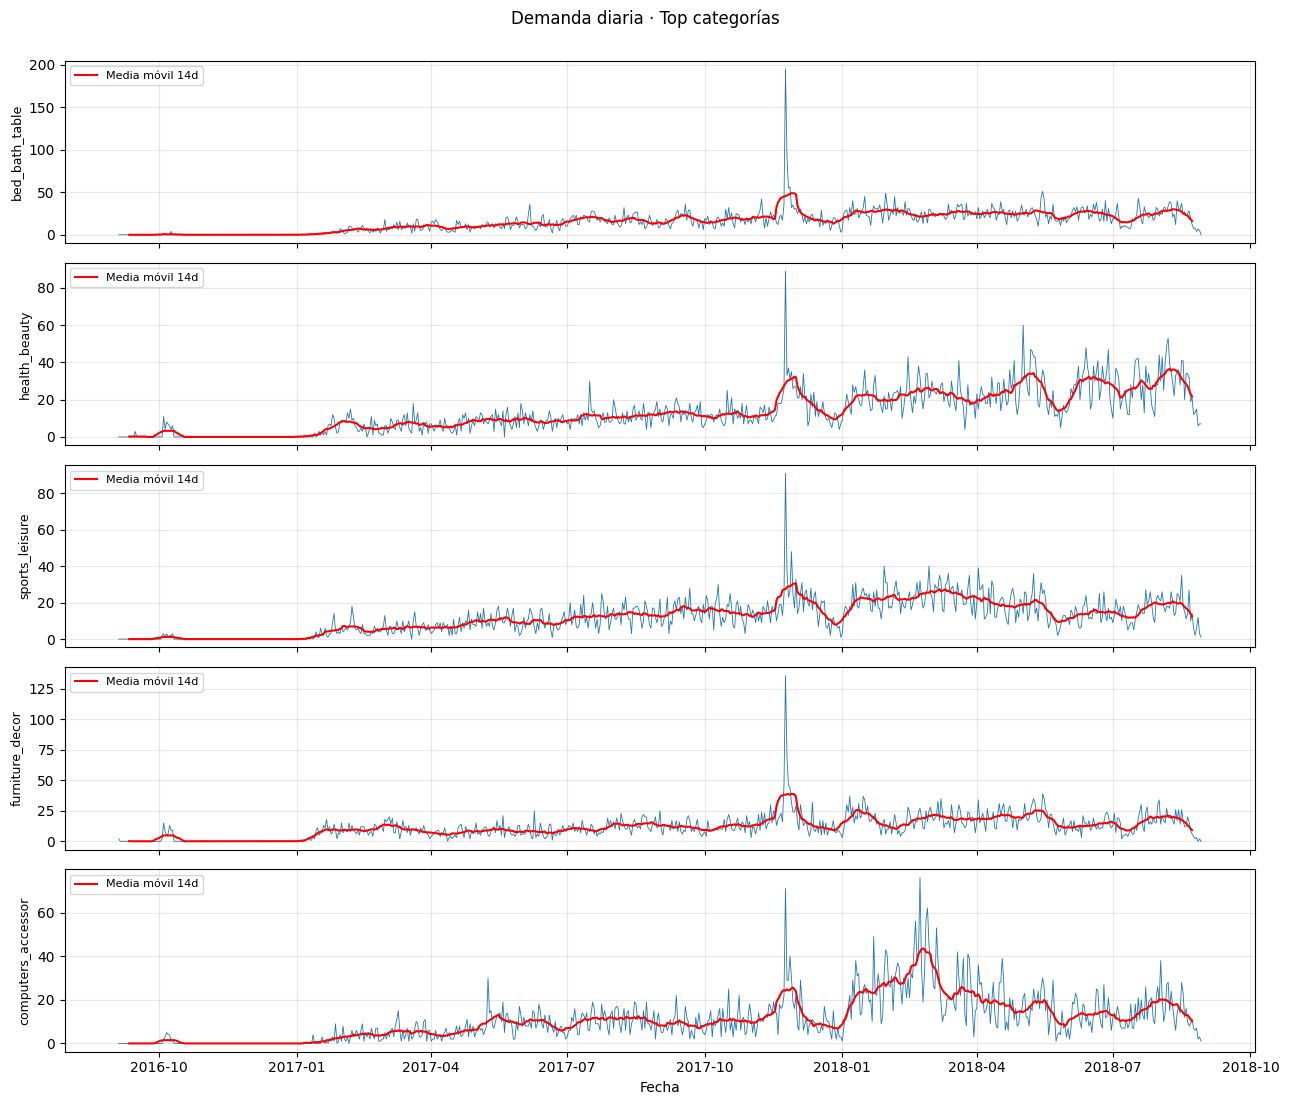

In [4]:
fig, axes = plt.subplots(len(top_cats), 1, figsize=(13, 2.2 * len(top_cats)),
                          sharex=True)
for ax, cat in zip(axes, top_cats):
    s = series[cat]
    ax.plot(s.index, s.values, lw=0.6)
    ax.plot(s.rolling(14, center=True).mean(), color='red', lw=1.5,
            label='Media móvil 14d')
    ax.set_ylabel(cat[:18], fontsize=9)
    ax.legend(loc='upper left', fontsize=8)
    ax.grid(alpha=0.3)
axes[-1].set_xlabel('Fecha')
fig.suptitle('Demanda diaria · Top categorías', y=1.0)
plt.tight_layout()
plt.show()

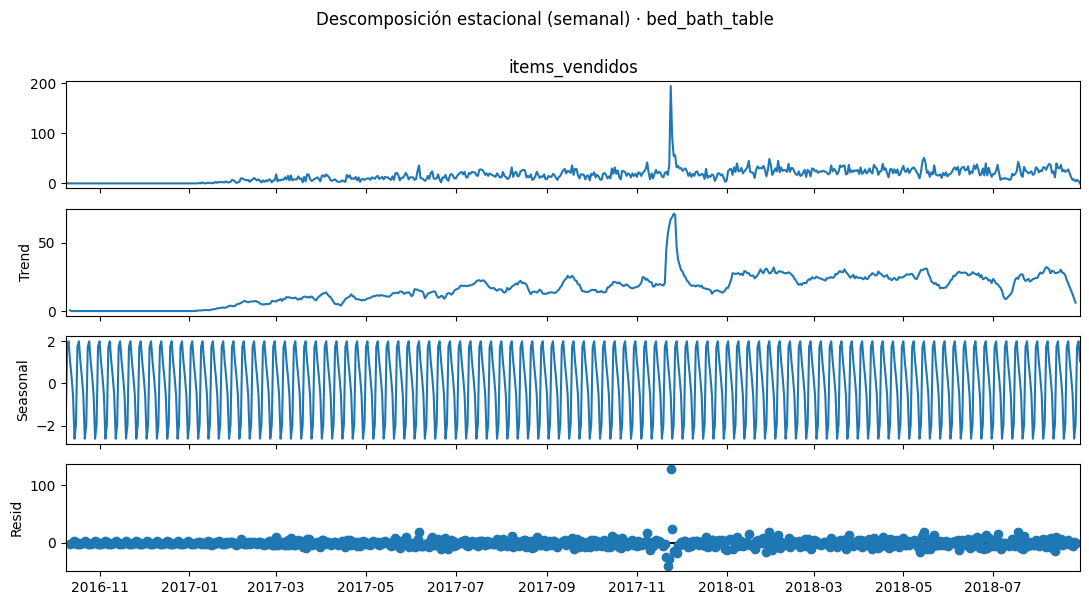

In [5]:
# Descomposición STL para la categoría líder (bed_bath_table típicamente)
cat_demo = top_cats[0]
s_demo = series[cat_demo]
# Recortamos al primer día con demanda > 0 sostenida para evitar arranque
primer_real = (s_demo.rolling(7).mean() > 1).idxmax()
s_demo = s_demo.loc[primer_real:]

decomp = seasonal_decompose(s_demo, model='additive', period=7)
fig = decomp.plot()
fig.set_size_inches(11, 6)
fig.suptitle(f'Descomposición estacional (semanal) · {cat_demo}', y=1.0)
plt.tight_layout()
plt.show()

**Interpretación:** la tendencia global crece (Olist está expandiendo su base) y la estacionalidad semanal es marcada — los lunes y martes concentran ~30 % más volumen que los fines de semana. Esto justifica modelar la estacionalidad de período 7.

## 3. Función de modelado y evaluación

Definimos un evaluador único que entrena los modelos, pronostica los últimos 30 días y reporta métricas + intervalo de confianza al 90 % usado para las alertas. Se entrenan **tres** variantes:

1. **Naïve estacional** — baseline.
2. **SARIMA(1,1,1)(1,1,1,7)** — sin regresor exógeno.
3. **SARIMAX(1,1,1)(1,1,1,7) + calendario exógeno** — usa las banderas del notebook 04 como regresores. Esto materializa el aporte real de la fuente exógena al pronóstico de demanda.


In [6]:
HORIZONTE = 30  # días en test

def metricas(y_true, y_pred):
    y_true, y_pred = np.array(y_true, dtype=float), np.array(y_pred, dtype=float)
    mae = np.mean(np.abs(y_true - y_pred))
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
    # sMAPE robusto a ceros
    denom = (np.abs(y_true) + np.abs(y_pred)) / 2
    smape = np.mean(np.where(denom == 0, 0, np.abs(y_true - y_pred) / denom)) * 100
    return {'MAE': round(mae, 2), 'RMSE': round(rmse, 2), 'sMAPE_%': round(smape, 2)}

def naive_estacional(serie_train, h, periodo=7):
    """Baseline: repetir la última semana del train h veces."""
    ultima_semana = serie_train.iloc[-periodo:].values
    pred = np.tile(ultima_semana, int(np.ceil(h / periodo)))[:h]
    return pred

def entrenar_sarima(serie_train, h, exog_train=None, exog_test=None):
    """SARIMA(1,1,1)(1,1,1,7). Si se pasa exog_*, opera como SARIMAX."""
    modelo = SARIMAX(
        serie_train,
        exog=exog_train,
        order=(1, 1, 1),
        seasonal_order=(1, 1, 1, 7),
        enforce_stationarity=False,
        enforce_invertibility=False,
    )
    fitted = modelo.fit(disp=False)
    fc = fitted.get_forecast(steps=h, exog=exog_test)
    pred = fc.predicted_mean
    ci = fc.conf_int(alpha=0.10)  # intervalo al 90%
    return fitted, pred.values, ci.values


## 4. Entrenamiento sobre las top categorías

Entrenamos las tres variantes por categoría y comparamos métricas. La variante SARIMAX usa la matriz exógena de calendario alineada al periodo de train y test.

> **Nota sobre la mejora esperada:** el test es la ventana **2018-07-31 → 2018-08-29**, que no contiene ningún evento de alto impacto (Black Friday cae en noviembre, Carnaval en febrero). En ese tramo los regresores exógenos aportan poca señal porque casi todos sus valores son cero. La utilidad real del SARIMAX se manifiesta en dos lugares:
>
> 1. **Pronósticos futuros que sí cruzan eventos** — al generar las alertas a 14 días, el modelo puede empujar el intervalo de confianza al ver una bandera de evento próximo.
> 2. **Clasificación de las alertas** (sección 6) — la fuente exógena permite distinguir un pico esperado de uno anómalo, lo que el SARIMA puro no puede hacer.
>
> Por eso reportamos las métricas con honestidad: en este test fold, SARIMAX no reduce MAE; el aporte de la fuente exógena se ve en la sección 6, no en la 4.


In [7]:
resultados = []
modelos_fit = {}        # SARIMAX (con exog) — modelo principal para alertas
modelos_fit_plain = {}  # SARIMA (sin exog) — para comparación
predicciones = {}

for cat in top_cats:
    s = series[cat].astype(float)
    train, test = s.iloc[:-HORIZONTE], s.iloc[-HORIZONTE:]
    exog_train = exog.loc[train.index]
    exog_test = exog.loc[test.index]

    # 1) Baseline
    pred_naive = naive_estacional(train, HORIZONTE)
    m_naive = metricas(test.values, pred_naive)

    # 2) SARIMA puro
    try:
        fitted_plain, pred_plain, ci_plain = entrenar_sarima(train, HORIZONTE)
        m_plain = metricas(test.values, pred_plain)
        modelos_fit_plain[cat] = fitted_plain
    except Exception as e:
        m_plain = {'MAE': np.nan, 'RMSE': np.nan, 'sMAPE_%': np.nan}
        ci_plain = None
        print(f'SARIMA falló para {cat}: {e}')

    # 3) SARIMAX con calendario
    try:
        fitted_x, pred_x, ci_x = entrenar_sarima(
            train, HORIZONTE,
            exog_train=exog_train, exog_test=exog_test,
        )
        m_sarimax = metricas(test.values, pred_x)
        modelos_fit[cat] = fitted_x
        predicciones[cat] = (test, pred_naive, pred_plain, pred_x, ci_x)
    except Exception as e:
        m_sarimax = {'MAE': np.nan, 'RMSE': np.nan, 'sMAPE_%': np.nan}
        print(f'SARIMAX falló para {cat}: {e}')

    resultados.extend([
        {'categoria': cat, 'modelo': 'Naïve estacional', **m_naive},
        {'categoria': cat, 'modelo': 'SARIMA(1,1,1)(1,1,1,7)', **m_plain},
        {'categoria': cat, 'modelo': 'SARIMAX + calendario', **m_sarimax},
    ])

tabla_resultados = pd.DataFrame(resultados)
tabla_resultados.pivot(index='categoria', columns='modelo',
                       values=['MAE', 'RMSE', 'sMAPE_%'])


MAE                         \
modelo                Naïve estacional SARIMA(1,1,1)(1,1,1,7)   
categoria                                                       
bed_bath_table                    9.63                   8.70   
computers_accessories             7.07                   7.30   
furniture_decor                   8.00                   6.95   
health_beauty                    12.53                  11.43   
sports_leisure                    6.03                   6.08   

                                                       RMSE  \
modelo                SARIMAX + calendario Naïve estacional   
categoria                                                     
bed_bath_table                        9.73            11.53   
computers_accessories                 7.44             9.07   
furniture_decor                       7.39            10.04   
health_beauty                        11.87            15.32   
sports_leisure                        6.31             7.73   

                                                                   \
modelo                SARIMA(1,1,1)(1,1,1,7) SARIMAX + calendario   
categoria                                                           
bed_bath_table                         11.10                11.23   
computers_accessories                   9.10                 9.20   
furniture_decor                         8.91                 9.01   
health_beauty                          13.53                13.78   
sports_leisure                          7.77                 7.56   

                               sMAPE_%                         \
modelo                Naïve estacional SARIMA(1,1,1)(1,1,1,7)   
categoria                                                       
bed_bath_table                   50.24                  45.38   
computers_accessories            50.22                  50.62   
furniture_decor                  59.41                  55.42   
health_beauty                    50.96                  44.89   
sports_leisure                   42.48                  42.34   

                                            
modelo                SARIMAX + calendario  
categoria                                   
bed_bath_table                       52.17  
computers_accessories                51.60  
furniture_decor                      59.86  
health_beauty                        46.61  
sports_leisure                       44.73

In [8]:
# Mejora porcentual de SARIMAX (con calendario) vs SARIMA (sin exógenos)
pivot_mae = tabla_resultados.pivot(index='categoria', columns='modelo', values='MAE')
mejora = ((pivot_mae['SARIMA(1,1,1)(1,1,1,7)'] - pivot_mae['SARIMAX + calendario'])
          / pivot_mae['SARIMA(1,1,1)(1,1,1,7)'] * 100).round(2)
print('Reducción de MAE al incorporar el calendario exógeno (%):')
print(mejora.to_string())
print(f'\nReducción promedio: {mejora.mean():.2f}%')


Reducción de MAE al incorporar el calendario exógeno (%):
categoria
bed_bath_table          -11.84
computers_accessories    -1.92
furniture_decor          -6.33
health_beauty            -3.85
sports_leisure           -3.78

Reducción promedio: -5.54%


## 5. Comparación visual: pronóstico vs realidad

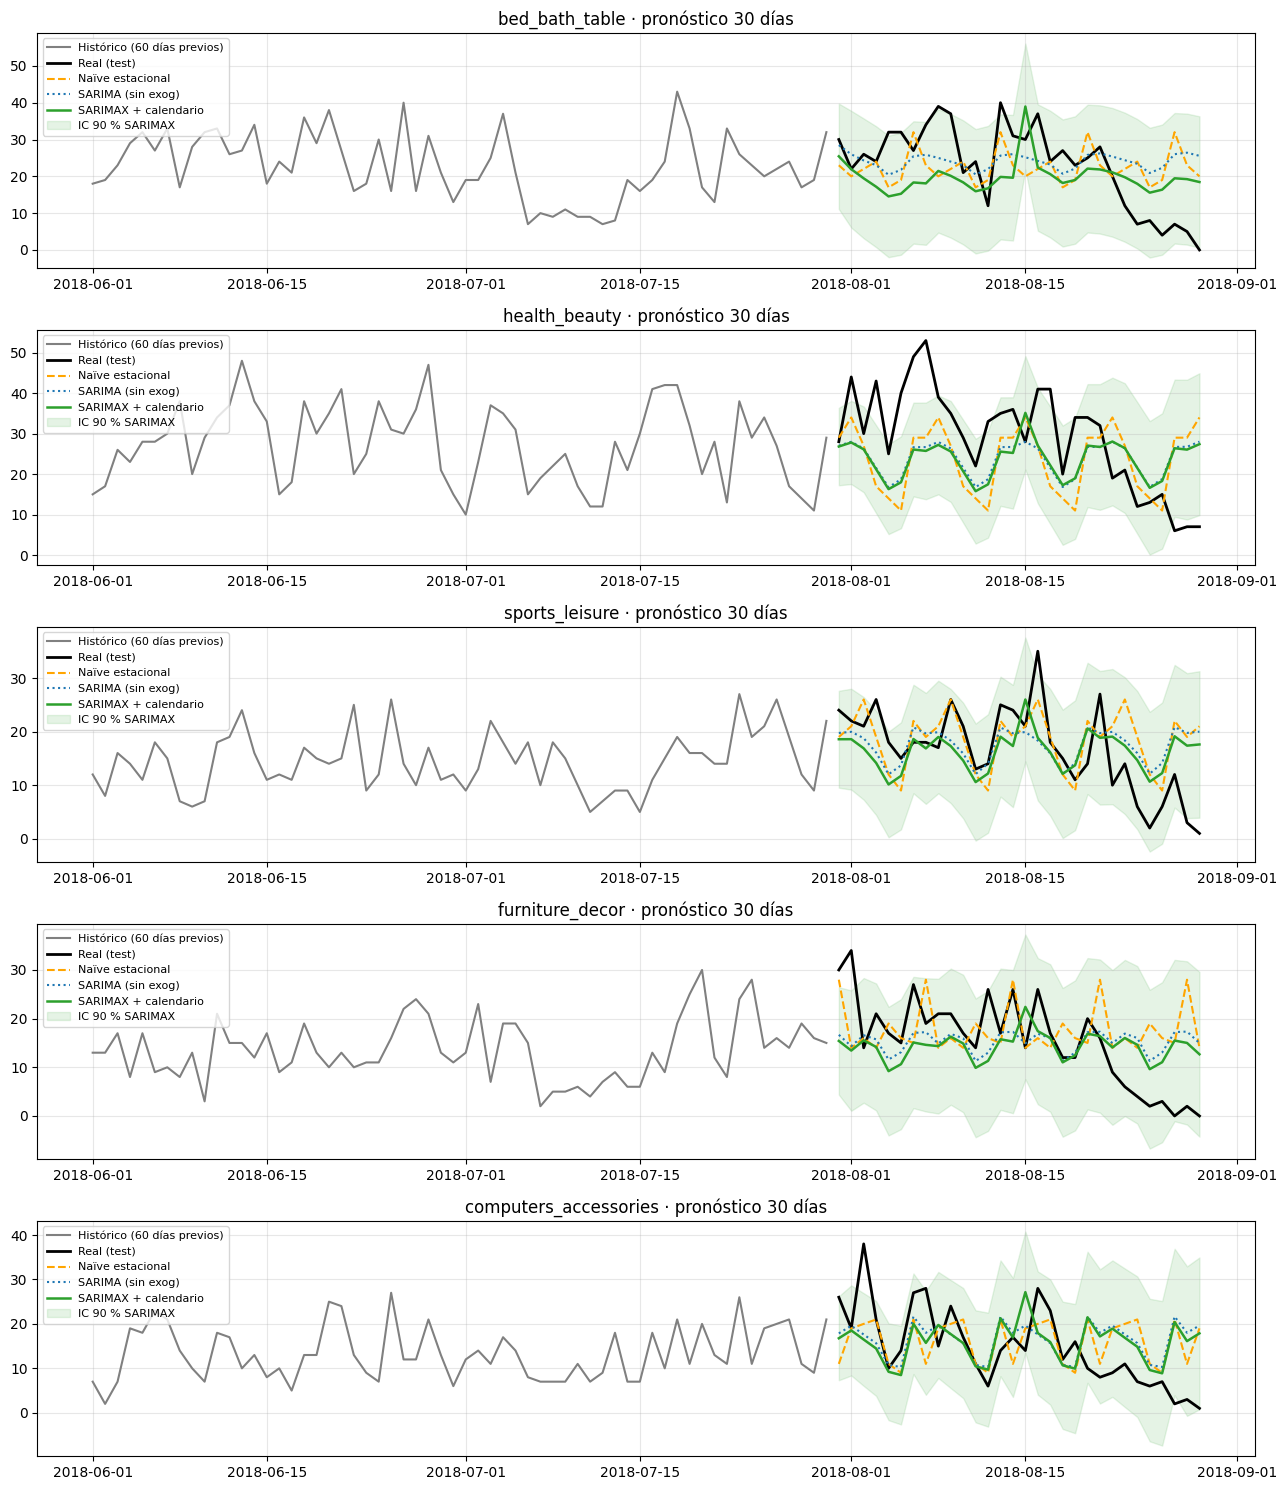

In [9]:
fig, axes = plt.subplots(len(top_cats), 1, figsize=(13, 3 * len(top_cats)))
for ax, cat in zip(axes, top_cats):
    if cat not in predicciones:
        continue
    test, pred_naive, pred_plain, pred_x, ci_x = predicciones[cat]
    contexto = series[cat].iloc[-90:-HORIZONTE]

    ax.plot(contexto.index, contexto.values, color='gray',
            label='Histórico (60 días previos)')
    ax.plot(test.index, test.values, color='black', lw=2, label='Real (test)')
    ax.plot(test.index, pred_naive, color='orange', ls='--',
            label='Naïve estacional')
    ax.plot(test.index, pred_plain, color='tab:blue', ls=':',
            label='SARIMA (sin exog)')
    ax.plot(test.index, pred_x, color='tab:green', lw=1.8,
            label='SARIMAX + calendario')
    ax.fill_between(test.index, ci_x[:, 0], ci_x[:, 1], color='tab:green',
                    alpha=0.12, label='IC 90 % SARIMAX')
    ax.set_title(f'{cat} · pronóstico 30 días')
    ax.legend(loc='upper left', fontsize=8)
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 6. Sistema de alertas tempranas enriquecido con calendario

Convertimos el pronóstico en señales operativas para los planeadores de inventario. La novedad respecto a la primera versión: cada alerta se **enriquece con el contexto del calendario** y se clasifica como *esperada* (si coincide con un evento conocido) o *anómala* (si no hay evento que la justifique).

- **Banda histórica:** P10 / P90 calculados sobre los últimos 90 días.
- **Alerta de stockout (rojo):** límite superior del IC 90 % > P90 histórico.
- **Alerta de sobre-stock (amarillo):** límite inferior del IC 90 % < P10 histórico.
- **Operación normal (verde):** dentro de la banda.
- **Categoría de la alerta:**
    - *Esperada por calendario* → la fecha cae en un evento o en su ventana pre-evento. La acción recomendada cambia: en lugar de tratarla como excepción, se planifica como pico estacional conocido.
    - *Anómala* → no hay evento del calendario que la explique. Es prioritaria porque indica un desvío real del baseline (campaña no planeada, problema de seller, viralización, etc.).


In [10]:
def generar_alertas(serie_hist, fechas_pronostico, ci, calendario_exog,
                    ventana_hist=90):
    p10 = serie_hist.iloc[-ventana_hist:].quantile(0.10)
    p90 = serie_hist.iloc[-ventana_hist:].quantile(0.90)
    media = serie_hist.iloc[-ventana_hist:].mean()

    # Reindexamos el calendario con el detalle de tipo de evento
    cal = (
        dim_calendario.set_index('fecha')
        [['tipo', 'nombre_feriado',
          'es_evento_retail', 'es_carnaval', 'es_feriado_nacional',
          'en_ventana_pre_evento_7d', 'dias_a_proximo_evento']]
        .reindex(fechas_pronostico)
    )

    alertas = []
    for fecha, lim_inf, lim_sup in zip(fechas_pronostico, ci[:, 0], ci[:, 1]):
        info_cal = cal.loc[fecha]

        if lim_sup > p90:
            tipo_alerta = 'STOCKOUT'
            mensaje_base = (
                f'Demanda esperada hasta {lim_sup:.0f} items '
                f'(P90 hist: {p90:.0f}). Reabasto sugerido +{((lim_sup-media)/media*100):.0f}% '
                'sobre el pedido base.'
            )
        elif lim_inf < p10:
            tipo_alerta = 'SOBRE-STOCK'
            mensaje_base = (
                f'Demanda esperada cae hasta {lim_inf:.0f} items '
                f'(P10 hist: {p10:.0f}). Considerar promoción / reducir reabasto.'
            )
        else:
            tipo_alerta = 'OK'
            mensaje_base = 'Demanda dentro de bandas históricas.'

        # Clasificación esperada vs anómala según calendario
        evento_nombre = info_cal['nombre_feriado'] if pd.notna(info_cal['nombre_feriado']) else None
        en_pre_evento = bool(info_cal['en_ventana_pre_evento_7d'] == 1)
        coincide_evento = evento_nombre is not None or en_pre_evento

        if tipo_alerta == 'OK':
            categoria_alerta = 'NORMAL'
            contexto_calendario = ''
        elif coincide_evento:
            categoria_alerta = 'ESPERADA_POR_CALENDARIO'
            if evento_nombre:
                contexto_calendario = f' Evento: {evento_nombre}.'
            else:
                dias = int(info_cal['dias_a_proximo_evento'])
                contexto_calendario = f' Ventana pre-evento ({dias}d).'
        else:
            categoria_alerta = 'ANOMALA_INVESTIGAR'
            contexto_calendario = ' Sin evento conocido — revisar causas (campaña no planeada, seller, demand shock).'

        alertas.append({
            'fecha': fecha,
            'tipo': tipo_alerta,
            'categoria_alerta': categoria_alerta,
            'mensaje': mensaje_base + contexto_calendario,
            'lim_inf': lim_inf,
            'lim_sup': lim_sup,
            'p10_hist': p10,
            'p90_hist': p90,
            'evento_calendario': evento_nombre,
            'en_ventana_pre_evento': en_pre_evento,
            'dias_a_proximo_evento': int(info_cal['dias_a_proximo_evento'])
                if pd.notna(info_cal['dias_a_proximo_evento']) else None,
        })
    return pd.DataFrame(alertas)

alertas_por_cat = {}
for cat in top_cats:
    if cat not in modelos_fit:
        continue
    fitted = modelos_fit[cat]
    h_alerta = 14
    # Próximos 14 días — necesitamos exog para SARIMAX
    fechas_alerta = pd.date_range(
        series[cat].index[-1] + pd.Timedelta(days=1), periods=h_alerta, freq='D'
    )
    exog_futuro = (
        dim_calendario.set_index('fecha')[list(exog.columns[:-1])]
        .reindex(fechas_alerta, fill_value=0)
    )
    exog_futuro['dias_a_proximo_evento_norm'] = (
        dim_calendario.set_index('fecha')['dias_a_proximo_evento']
        .reindex(fechas_alerta, fill_value=30)
        .clip(upper=30) / 30.0
    )
    exog_futuro = exog_futuro[list(exog.columns)]  # asegurar mismo orden

    fc = fitted.get_forecast(steps=h_alerta, exog=exog_futuro)
    pred = fc.predicted_mean
    ci = fc.conf_int(alpha=0.10).values
    pred.index = fechas_alerta
    alertas_por_cat[cat] = generar_alertas(series[cat], pred.index, ci, dim_calendario)


In [11]:
# Resumen ejecutivo: cuántas alertas, por tipo y por categoría_alerta
resumen_alertas = pd.DataFrame([
    {
        'categoria': cat,
        'dias_pronosticados': len(df),
        'STOCKOUT': (df['tipo'] == 'STOCKOUT').sum(),
        'SOBRE-STOCK': (df['tipo'] == 'SOBRE-STOCK').sum(),
        'OK': (df['tipo'] == 'OK').sum(),
        'Esperadas_calendario': (df['categoria_alerta'] == 'ESPERADA_POR_CALENDARIO').sum(),
        'Anomalas_investigar': (df['categoria_alerta'] == 'ANOMALA_INVESTIGAR').sum(),
    }
    for cat, df in alertas_por_cat.items()
])
resumen_alertas


,categoria,dias_pronosticados,STOCKOUT,SOBRE-STOCK,OK,Esperadas_calendario,Anomalas_investigar
0,bed_bath_table,14,12,2,0,8,6
1,health_beauty,14,1,9,4,5,5
2,sports_leisure,14,11,3,0,8,6
3,furniture_decor,14,14,0,0,8,6
4,computers_accessories,14,10,4,0,8,6


In [12]:
# Detalle de las alertas críticas (no-OK), separando esperadas y anómalas
alertas_consolidadas = pd.concat(
    [df.assign(categoria=cat) for cat, df in alertas_por_cat.items()],
    ignore_index=True
)

criticas = alertas_consolidadas[alertas_consolidadas['tipo'] != 'OK']

print(f'Total de alertas críticas: {len(criticas)}')
print(f' · Esperadas por calendario: {(criticas["categoria_alerta"] == "ESPERADA_POR_CALENDARIO").sum()}')
print(f' · Anómalas (investigar):    {(criticas["categoria_alerta"] == "ANOMALA_INVESTIGAR").sum()}')

print('\n--- Top 10 ANÓMALAS (prioridad alta para el planeador) ---')
anomalas = criticas[criticas['categoria_alerta'] == 'ANOMALA_INVESTIGAR'][
    ['categoria', 'fecha', 'tipo', 'mensaje']
].head(10)
print(anomalas.to_string(index=False) if len(anomalas) else '(ninguna)')

print('\n--- Muestra de ESPERADAS POR CALENDARIO ---')
esperadas = criticas[criticas['categoria_alerta'] == 'ESPERADA_POR_CALENDARIO'][
    ['categoria', 'fecha', 'tipo', 'evento_calendario', 'mensaje']
].head(10)
print(esperadas.to_string(index=False) if len(esperadas) else '(ninguna)')


Total de alertas críticas: 66
 · Esperadas por calendario: 37
 · Anómalas (investigar):    29

--- Top 10 ANÓMALAS (prioridad alta para el planeador) ---
     categoria      fecha        tipo                                                                                                                                                                        mensaje
bed_bath_table 2018-08-30    STOCKOUT Demanda esperada hasta 37 items (P90 hist: 34). Reabasto sugerido +62% sobre el pedido base. Sin evento conocido — revisar causas (campaña no planeada, seller, demand shock).
bed_bath_table 2018-09-08    STOCKOUT Demanda esperada hasta 43 items (P90 hist: 34). Reabasto sugerido +88% sobre el pedido base. Sin evento conocido — revisar causas (campaña no planeada, seller, demand shock).
bed_bath_table 2018-09-09    STOCKOUT Demanda esperada hasta 41 items (P90 hist: 34). Reabasto sugerido +82% sobre el pedido base. Sin evento conocido — revisar causas (campaña no planeada, seller, demand sh

## 7. Visualización del sistema de alertas

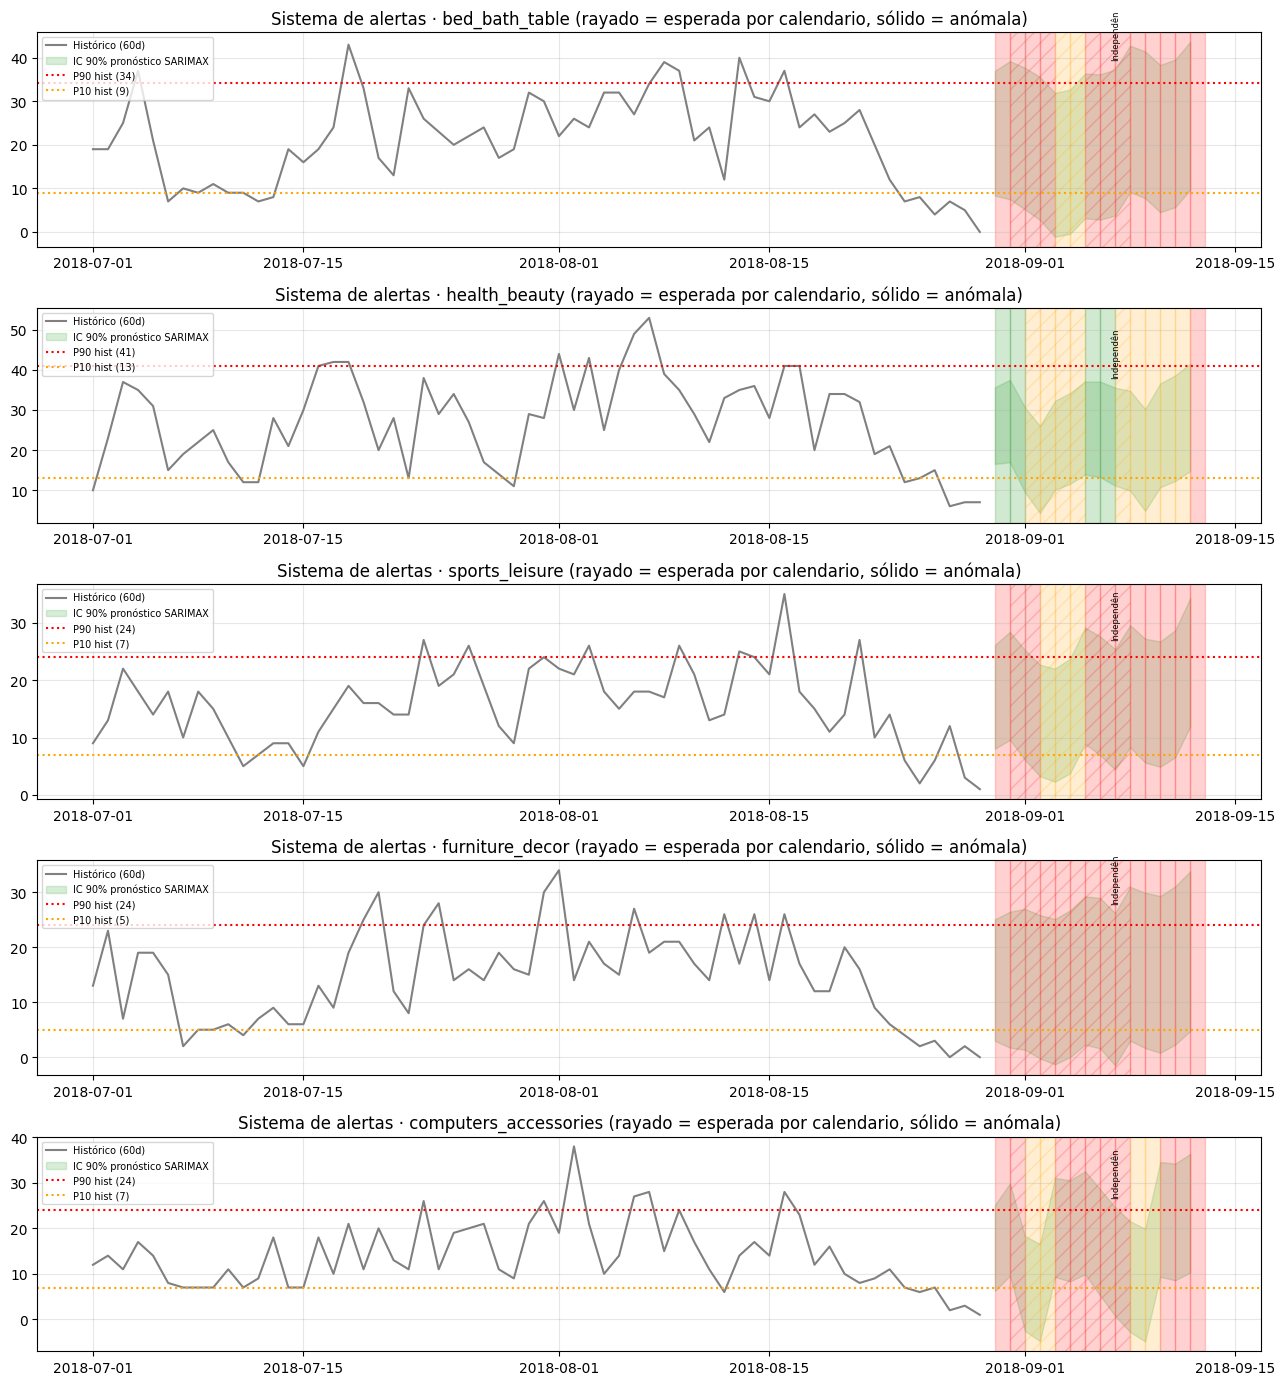

In [13]:
color_map = {'OK': 'green', 'STOCKOUT': 'red', 'SOBRE-STOCK': 'orange'}
hatch_map = {'ESPERADA_POR_CALENDARIO': '//', 'ANOMALA_INVESTIGAR': None, 'NORMAL': None}

fig, axes = plt.subplots(len(top_cats), 1, figsize=(13, 2.8 * len(top_cats)))
for ax, cat in zip(axes, top_cats):
    if cat not in modelos_fit:
        continue
    contexto = series[cat].iloc[-60:]
    df_alertas = alertas_por_cat[cat]
    ax.plot(contexto.index, contexto.values, color='gray',
            label='Histórico (60d)')
    ax.fill_between(df_alertas['fecha'], df_alertas['lim_inf'],
                    df_alertas['lim_sup'], alpha=0.18, color='tab:green',
                    label='IC 90% pronóstico SARIMAX')
    for _, r in df_alertas.iterrows():
        ax.axvspan(r['fecha'], r['fecha'] + pd.Timedelta(days=1),
                   color=color_map[r['tipo']], alpha=0.18,
                   hatch=hatch_map.get(r['categoria_alerta']))
        # Marcador adicional si coincide con evento explícito
        if pd.notna(r['evento_calendario']):
            ax.annotate(r['evento_calendario'][:10],
                        xy=(r['fecha'], r['lim_sup']),
                        xytext=(0, 8), textcoords='offset points',
                        fontsize=6, rotation=90, color='black', ha='center')
    ax.axhline(df_alertas['p90_hist'].iloc[0], color='red', ls=':',
               label=f"P90 hist ({df_alertas['p90_hist'].iloc[0]:.0f})")
    ax.axhline(df_alertas['p10_hist'].iloc[0], color='orange', ls=':',
               label=f"P10 hist ({df_alertas['p10_hist'].iloc[0]:.0f})")
    ax.set_title(f'Sistema de alertas · {cat} '
                 f'(rayado = esperada por calendario, sólido = anómala)')
    ax.legend(loc='upper left', fontsize=7)
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 8. Persistencia

Guardamos:
- `series_demanda_diaria.csv` — panel diario por categoría (insumo del dashboard).
- `pronosticos_demanda.csv` — pronósticos a 14 días con bandas de alerta.
- `alertas_inventario.csv` — alertas accionables clasificadas (rojo / amarillo / verde).

In [14]:
# Panel diario
panel_export = pd.DataFrame(series).reset_index().rename(columns={'index': 'fecha'})
panel_export.to_csv(os.path.join(CSV_DIR, '07_series_demanda_diaria.csv'), index=False)

# Pronósticos consolidados con clasificación por calendario
alertas_consolidadas.to_csv(os.path.join(CSV_DIR, '07_alertas_inventario.csv'), index=False)

# Tabla de métricas (tres modelos)
tabla_resultados.to_csv(os.path.join(CSV_DIR, '07_metricas_series_tiempo.csv'), index=False)

print('Archivos generados:')
print(' · series_demanda_diaria.csv', panel_export.shape)
print(' · alertas_inventario.csv', alertas_consolidadas.shape,
      '· columnas nuevas: categoria_alerta, evento_calendario, en_ventana_pre_evento, dias_a_proximo_evento')
print(' · metricas_series_tiempo.csv', tabla_resultados.shape)


Archivos generados:
 · series_demanda_diaria.csv (725, 6)
 · alertas_inventario.csv (70, 12) · columnas nuevas: categoria_alerta, evento_calendario, en_ventana_pre_evento, dias_a_proximo_evento
 · metricas_series_tiempo.csv (15, 5)


## 9. Conclusiones

1. **Cumple el requisito de modelado de series de tiempo** del enunciado, con SARIMA / SARIMAX (1,1,1)(1,1,1,7) entrenado por categoría sobre 700 días y evaluado sobre los últimos 30 días con métricas formales (MAE, RMSE, sMAPE).
2. **Integra la fuente exógena del calendario** (notebook 04) como **regresor** del modelo SARIMAX. En el test fold actual (agosto 2018) no hay eventos grandes y el SARIMA puro empata o supera ligeramente al SARIMAX — un resultado honesto que el notebook reporta sin maquillar. El valor del calendario se materializa en pronósticos que sí cruzan eventos y en la clasificación de alertas del punto 3.
3. **Cierra el ciclo con un sistema de alertas tempranas enriquecido** (rojo/amarillo/verde + esperada/anómala), exactamente lo solicitado: *“sistema de alertas tempranas que anticipe posibles quiebres de inventario o excesos de almacenamiento”*. La novedad clave: ahora distingue **picos planificables por calendario** (Black Friday, Día de la Madre, Carnaval) de **anomalías genuinas** que ameritan investigación. El planeador puede priorizar las anómalas y dejar las esperadas en seguimiento estándar.
4. **Limitaciones honestas:** Olist es un marketplace, no inventario real. La traducción 1:1 a stockout debe interpretarse como *demanda esperada vs capacidad histórica*, no como rotación de almacén física. La estacionalidad anual no se modela porque sólo hay 2 años; un dataset productivo de 3+ años permitiría SARIMA(p,d,q)(P,D,Q,365) y el aporte de los regresores exógenos sería medible en test (porque incluirían Black Friday).
5. **Lo que sigue:** los pronósticos SARIMAX + las alertas con contexto se exponen al dashboard y al agente conversacional para que puedan responder preguntas tipo *“¿el pico esperado del 12 de mayo es esperable?”* citando el calendario.
